# 1C - Sales prediction

## Part 1: Feature selection

In [1]:
import numpy as np
import pandas as pd
import dateutil
import datetime as dt
from datetime import date
from pandarallel import pandarallel
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
from tqdm.notebook import tqdm
import pickle

from itertools import permutations, product

import lightgbm as lgb

from lightgbm import LGBMRegressor
from lofo import LOFOImportance, FLOFOImportance, Dataset, plot_importance

from sklearn.metrics import (mean_squared_log_error, mean_squared_error,
                             mean_absolute_error)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split, KFold
import warnings

## Data preparation

In [2]:
alles = pd.read_pickle('data/alles_final.pkl')
alles = alles.drop(['mean_price', 'av_shop_item'], axis=1)

In [3]:
rows = alles['date_block_num'] > 11

In [4]:
features = alles.columns[(alles.columns!='item_cnt_month')]

In [5]:
alles[['item_name', 'item_category', 'item_subcategory', 'city', 'shop_type']] = \
alles[['item_name', 'item_category',
       'item_subcategory', 'city', 'shop_type']].apply(LabelEncoder().fit_transform)

In [6]:
data = alles.loc[rows, list(features)+['item_cnt_month']]
data = data.fillna(0)

In [7]:
train_rows = data.date_block_num < 33
test_rows = data.date_block_num == 33

In [8]:
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

## LOFO Importance

LGBM parameters evaluated using Optuna (see, for example, https://www.kaggle.com/code1110/eda-optimizing-lightgbm-hyperparameters):

In [9]:
params = pd.read_pickle('data/final_params.pkl')

In [10]:
params

{'lambda_l1': 1.3008079402372022e-06,
 'lambda_l2': 1.2408041392583668e-05,
 'num_leaves': 111,
 'feature_fraction': 0.400470665528579,
 'bagging_fraction': 0.7563778960461363,
 'bagging_freq': 6,
 'min_child_samples': 37,
 'eta': 0.1,
 'metric': 'rmse'}

Training the LGBM regressor:

In [11]:
features = data.columns[data.columns!='item_cnt_month']

model = LGBMRegressor(**params)

model.fit(
    X_train, 
    y_train, 
    eval_metric="rmse", 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=25,
    early_stopping_rounds = 10)

Training until validation scores don't improve for 10 rounds
[25]	training's rmse: 0.786106	valid_1's rmse: 0.855271
[50]	training's rmse: 0.742736	valid_1's rmse: 0.85599
Early stopping, best iteration is:
[40]	training's rmse: 0.756757	valid_1's rmse: 0.847197


LGBMRegressor(bagging_fraction=0.7563778960461363, bagging_freq=6,
              boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
              eta=0.1, feature_fraction=0.400470665528579,
              importance_type='split', lambda_l1=1.3008079402372022e-06,
              lambda_l2=1.2408041392583668e-05, learning_rate=0.1, max_depth=-1,
              metric='rmse', min_child_samples=37, min_child_weight=0.001,
              min_split_gain=0.0, n_estimators=100, n_jobs=-1, num_leaves=111,
              objective=None, random_state=None, reg_alpha=0.0, reg_lambda=0.0,
              silent=True, subsample=1.0, subsample_for_bin=200000,
              subsample_freq=0)

Calculating feature importances based on the 33th month score:

In [12]:
lofo_imp = FLOFOImportance(trained_model=model, features=features,
                           target='item_cnt_month', validation_df=data[data['date_block_num']==33],
                          scoring='neg_mean_squared_error')

importance_df = lofo_imp.get_importance()

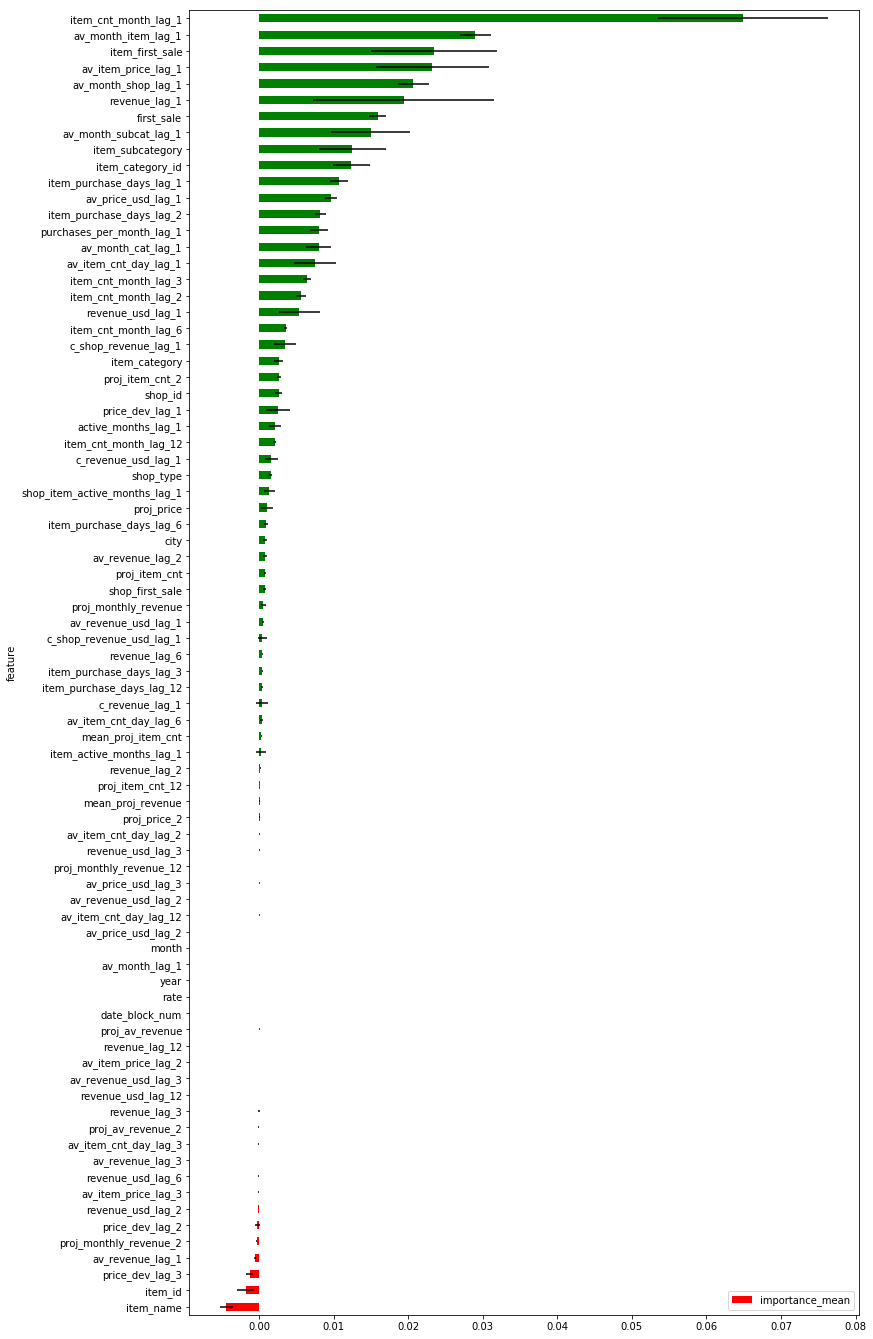

In [13]:
plot_importance(importance_df, figsize=(12,24))

Getting rid of the features that do not contribute to the score (or contribute negatively):

In [14]:
new_features=importance_df.loc[importance_df['importance_mean']>0,'feature'].values
features = list(new_features) + ['date_block_num']
cols = list(features)+['item_cnt_month']
data = alles.loc[rows, cols]
data = data.fillna(0)
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

Training the model again:

In [15]:
model = LGBMRegressor(**params)

model.fit(
    X_train, 
    y_train, 
    eval_metric="rmse", 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=25, 
    early_stopping_rounds = 10)

Training until validation scores don't improve for 10 rounds
[25]	training's rmse: 0.797094	valid_1's rmse: 0.842382
[50]	training's rmse: 0.765458	valid_1's rmse: 0.833221
[75]	training's rmse: 0.751458	valid_1's rmse: 0.831228
Early stopping, best iteration is:
[88]	training's rmse: 0.745781	valid_1's rmse: 0.830366


LGBMRegressor(bagging_fraction=0.7563778960461363, bagging_freq=6,
              boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
              eta=0.1, feature_fraction=0.400470665528579,
              importance_type='split', lambda_l1=1.3008079402372022e-06,
              lambda_l2=1.2408041392583668e-05, learning_rate=0.1, max_depth=-1,
              metric='rmse', min_child_samples=37, min_child_weight=0.001,
              min_split_gain=0.0, n_estimators=100, n_jobs=-1, num_leaves=111,
              objective=None, random_state=None, reg_alpha=0.0, reg_lambda=0.0,
              silent=True, subsample=1.0, subsample_for_bin=200000,
              subsample_freq=0)

Calculating feature importances again:

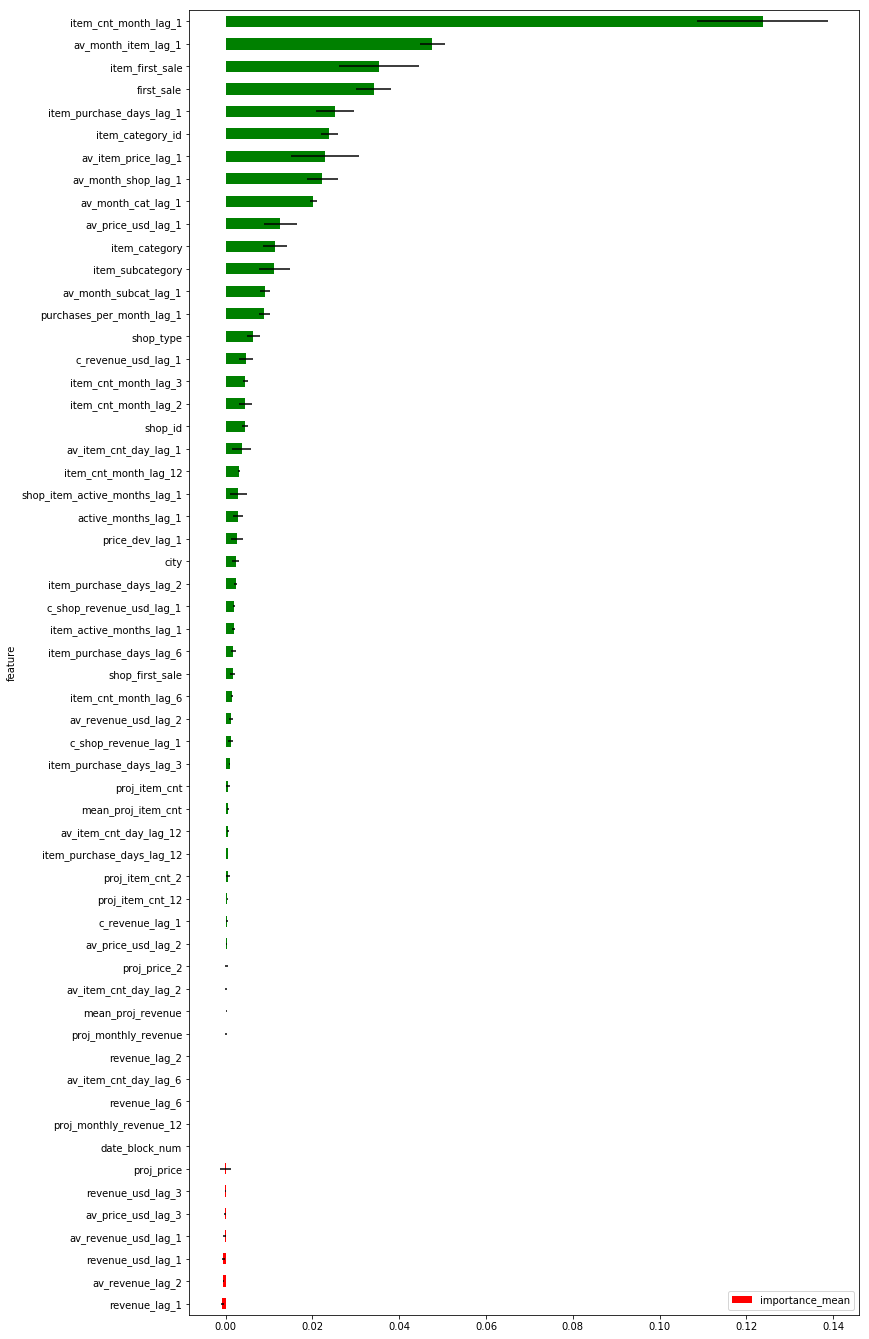

In [16]:
lofo_imp = FLOFOImportance(trained_model=model, features=features,
                           target='item_cnt_month',
                           validation_df=data.loc[data.date_block_num == 33, cols],
                          scoring='neg_mean_squared_error')

importance_df = lofo_imp.get_importance()

plot_importance(importance_df, figsize=(12,24))

Repeating the whole process one more time:

In [17]:
new_features=importance_df.loc[importance_df['importance_mean']>0,'feature'].values
features = list(new_features) + ['date_block_num']
cols = list(features)+['item_cnt_month']
data = alles.loc[rows, cols]
data = data.fillna(0)
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

In [18]:
model = LGBMRegressor(**params)

model.fit(
    X_train, 
    y_train, 
    eval_metric="rmse", 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=25, 
    early_stopping_rounds = 10)

Training until validation scores don't improve for 10 rounds
[25]	training's rmse: 0.798257	valid_1's rmse: 0.848148
[50]	training's rmse: 0.765149	valid_1's rmse: 0.839898
[75]	training's rmse: 0.750073	valid_1's rmse: 0.839074
[100]	training's rmse: 0.740958	valid_1's rmse: 0.837707
Did not meet early stopping. Best iteration is:
[100]	training's rmse: 0.740958	valid_1's rmse: 0.837707


LGBMRegressor(bagging_fraction=0.7563778960461363, bagging_freq=6,
              boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
              eta=0.1, feature_fraction=0.400470665528579,
              importance_type='split', lambda_l1=1.3008079402372022e-06,
              lambda_l2=1.2408041392583668e-05, learning_rate=0.1, max_depth=-1,
              metric='rmse', min_child_samples=37, min_child_weight=0.001,
              min_split_gain=0.0, n_estimators=100, n_jobs=-1, num_leaves=111,
              objective=None, random_state=None, reg_alpha=0.0, reg_lambda=0.0,
              silent=True, subsample=1.0, subsample_for_bin=200000,
              subsample_freq=0)

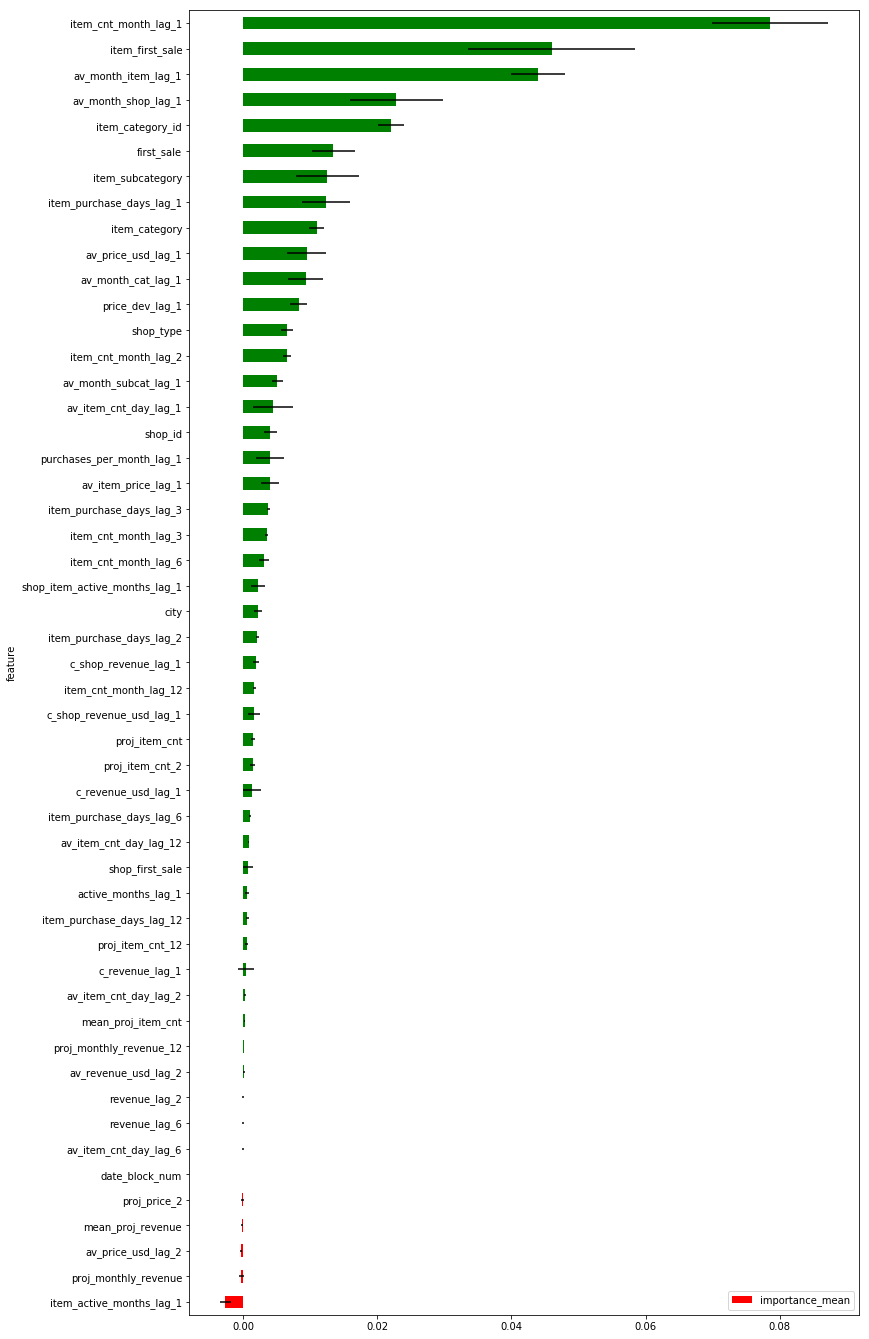

In [19]:
lofo_imp = FLOFOImportance(trained_model=model, features=features,
                           target='item_cnt_month',
                           validation_df=data.loc[data.date_block_num == 33, cols],
                          scoring='neg_mean_squared_error')

importance_df = lofo_imp.get_importance()

plot_importance(importance_df, figsize=(12,24))

Repeating one more time:

In [20]:
new_features=importance_df.loc[importance_df['importance_mean']>0,'feature'].values
features = list(new_features) + ['date_block_num']
cols = list(features)+['item_cnt_month']
data = alles.loc[rows, cols]
data = data.fillna(0)
X_train = data[train_rows].drop(['item_cnt_month'], axis=1)
y_train = data[train_rows]['item_cnt_month']
X_test = data[test_rows].drop(['item_cnt_month'], axis=1)
y_test = data[test_rows]['item_cnt_month']

X_final_test = data[data.date_block_num == 34].drop(['item_cnt_month'], axis=1)

In [21]:
model = LGBMRegressor(**params)

model.fit(
    X_train, 
    y_train, 
    eval_metric="rmse", 
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=25, 
    early_stopping_rounds = 10)

Training until validation scores don't improve for 10 rounds
[25]	training's rmse: 0.802257	valid_1's rmse: 0.845879
[50]	training's rmse: 0.769221	valid_1's rmse: 0.834209
[75]	training's rmse: 0.754137	valid_1's rmse: 0.831973
Early stopping, best iteration is:
[72]	training's rmse: 0.755608	valid_1's rmse: 0.83163


LGBMRegressor(bagging_fraction=0.7563778960461363, bagging_freq=6,
              boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
              eta=0.1, feature_fraction=0.400470665528579,
              importance_type='split', lambda_l1=1.3008079402372022e-06,
              lambda_l2=1.2408041392583668e-05, learning_rate=0.1, max_depth=-1,
              metric='rmse', min_child_samples=37, min_child_weight=0.001,
              min_split_gain=0.0, n_estimators=100, n_jobs=-1, num_leaves=111,
              objective=None, random_state=None, reg_alpha=0.0, reg_lambda=0.0,
              silent=True, subsample=1.0, subsample_for_bin=200000,
              subsample_freq=0)

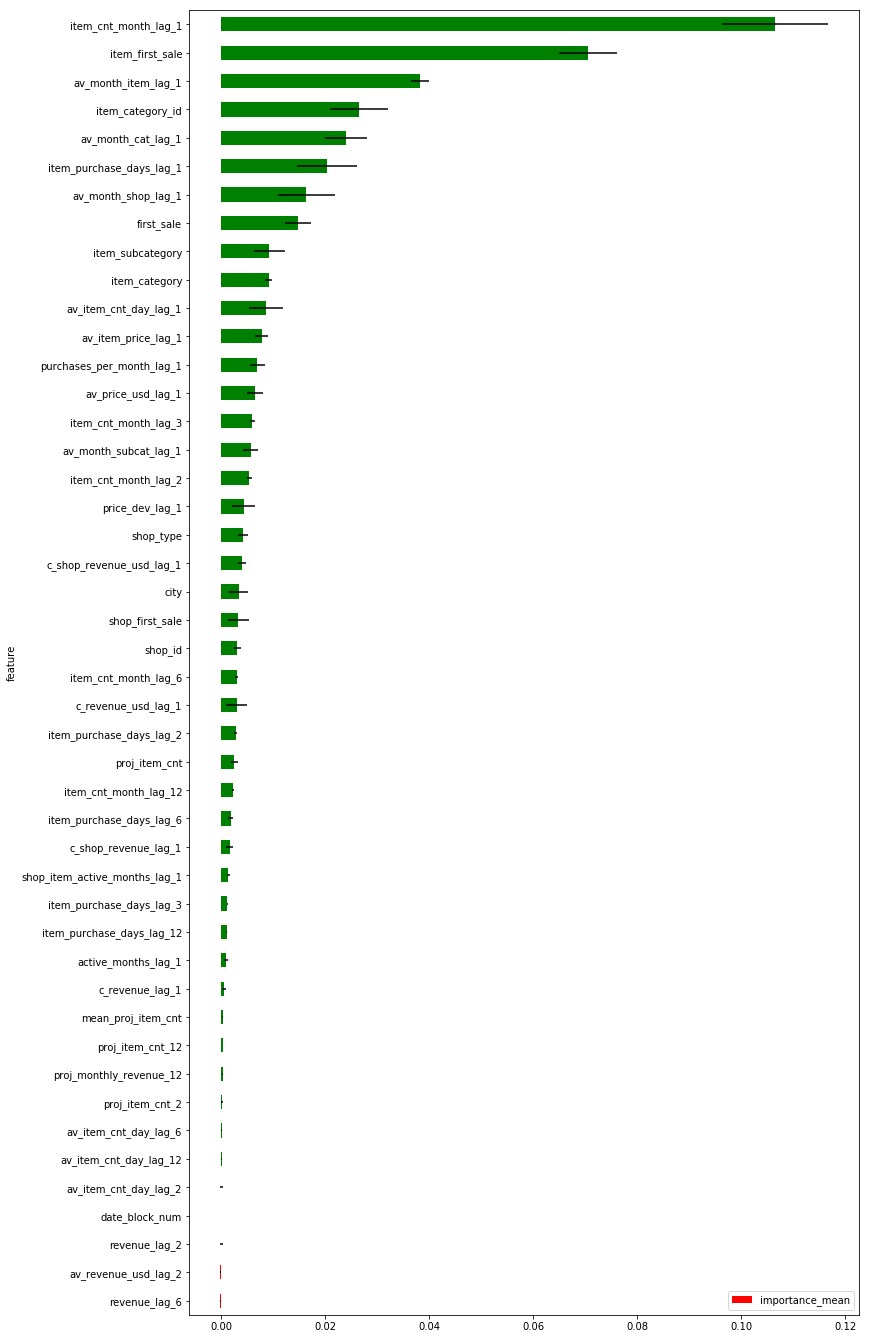

In [22]:
lofo_imp = FLOFOImportance(trained_model=model, features=features,
                           target='item_cnt_month',
                           validation_df=data.loc[data.date_block_num == 33, cols],
                          scoring='neg_mean_squared_error')

importance_df = lofo_imp.get_importance()

plot_importance(importance_df, figsize=(12,24))

In [23]:
new_features=importance_df.loc[importance_df['importance_mean']>0,'feature'].values

Saving the selected features:

In [25]:
with open('data/feature_importances.pkl', 'wb') as handle:
    pickle.dump(importance_df, handle)

In [24]:
with open('data/new_features.pkl', 'wb') as handle:
    pickle.dump(new_features, handle)